# Methods Tutorial: Fine-Tuning Whisper with LoRA

## Introduction

This tutorial teaches how to fine-tune **OpenAI Whisper large-v3-turbo** using **LoRA (Low-Rank Adaptation)**.

LoRA is a parameter-efficient fine-tuning method: instead of updating all ~809 M Whisper parameters, we freeze the base model and train small low-rank adapter matrices inside selected attention layers.

Everything needed for the demo is generated inside this notebook. The audio examples are mock 16 kHz waveforms with short transcripts, so no external dataset files are required.

### What You'll Learn

By the end of this tutorial, you will understand:

- Why full fine-tuning Whisper can be expensive
- How LoRA reduces the number of trainable parameters
- How to create mock ASR training data
- How Whisper audio inputs and text labels are prepared
- How LoRA adapters are attached to Whisper attention projections
- How to run a tiny training smoke test safely
- How to inspect trainable vs frozen parameters


## Tutorial Layout

| Part | Section | Topic |
|------|---------|-------|
| **Opening** | Introduction | Goals, scope, and what you will learn |
| **Opening** | Overview | LoRA fine-tuning pipeline |
| **Background** | A | What is LoRA? |
| **Background** | B | Why LoRA for Whisper? |
| **Background** | C | Mock ASR training data |
| **Setup** | - | Install from `requirements.txt` |
| **Setup** | 1 | Import libraries |
| **Setup** | 2 | Define helper functions |
| **Setup** | 3 | Create mock data |
| **Implementation** | 4 | Step 1 - Load Whisper large-v3-turbo |
| **Implementation** | 5 | Step 2 - Prepare model inputs and labels |
| **Implementation** | 6 | Step 3 - Attach LoRA adapters |
| **Implementation** | 7 | Step 4 - Run a training smoke test |
| **Visualization** | 8 | Trainable parameter and loss diagnostics |
| **Summary** | 9 | Flow summary and key point |
| **Conclusion** | 10 | What you learned and next steps |


## Overview

LoRA fine-tuning follows this pipeline:

1. Create or load paired audio/transcript examples
2. Convert audio into Whisper log-mel features
3. Convert transcripts into decoder labels
4. Load the Whisper model
5. Freeze the base model weights
6. Insert small trainable LoRA adapter matrices into attention projections
7. Train only the adapter weights

```text
Mock audio + transcript -> processor -> input_features + labels
                                  -> Whisper large-v3-turbo + LoRA adapters
                                  -> loss -> optimizer updates LoRA only
```

This tutorial uses `openai/whisper-large-v3-turbo` as the target checkpoint. Because that model is large, the real training smoke test is resource-aware: it runs automatically on CUDA and otherwise explains how to enable it.


## A. What Is LoRA?

**LoRA (Low-Rank Adaptation)** fine-tunes a model by adding small trainable matrices to existing weight matrices.

For a frozen weight matrix `W`, LoRA learns an update:

$$W' = W + \Delta W$$

where:

$$\Delta W = B A$$

- `W` is the original frozen model weight
- `A` and `B` are small trainable low-rank matrices
- `r` is the LoRA rank, controlling adapter capacity

Instead of training every parameter in `W`, LoRA trains only `A` and `B`. This greatly reduces memory and storage needs.

### How LoRA works visually

During training, input **x** flows through **two parallel paths**. The results are added together:

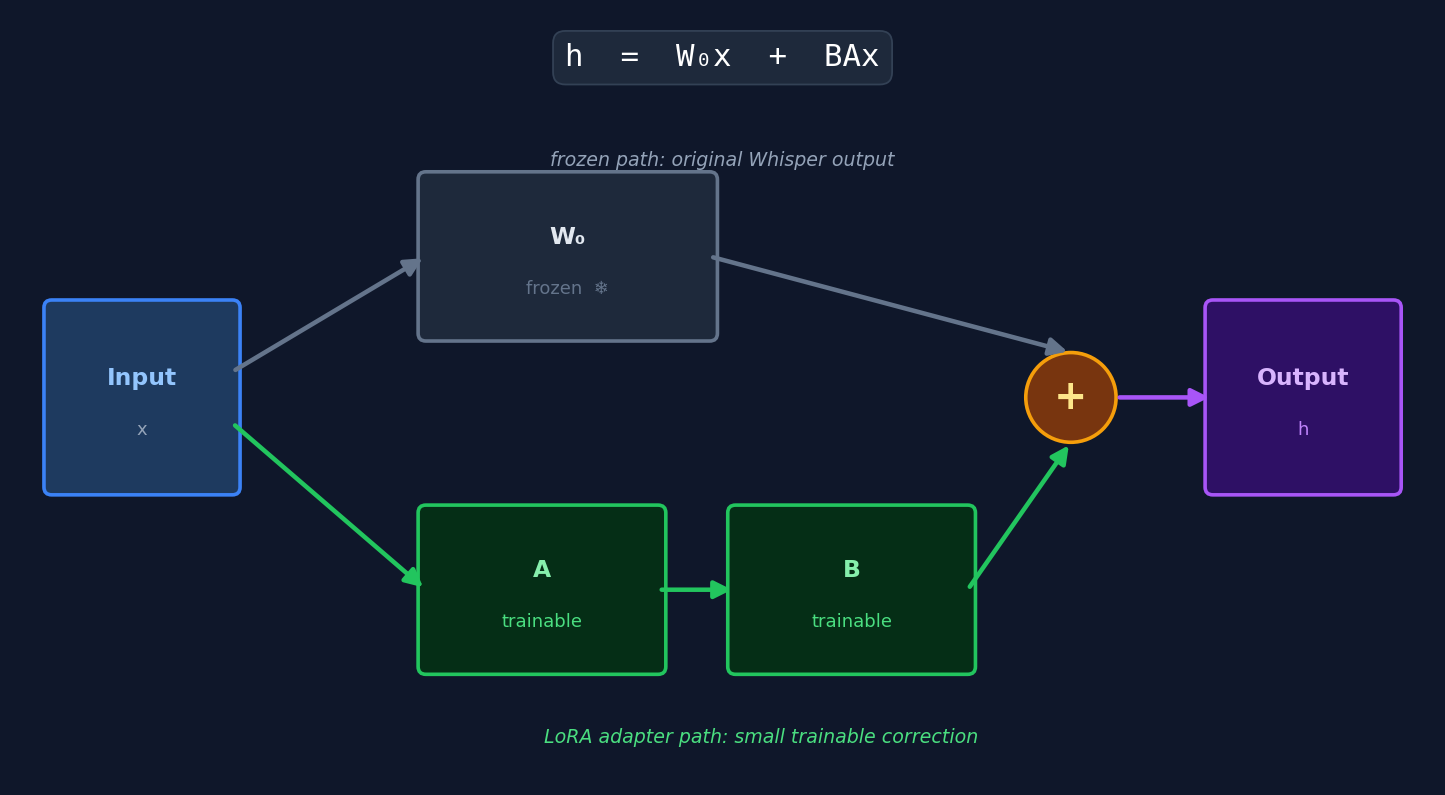

**Grey path (top):** Input goes through the original frozen weights **W₀**. These never change.

**Green path (bottom):** Input also goes through two small trainable matrices **A** then **B**. Only these are updated during training.

**Orange node:** The two outputs are added together to produce the final output **h**.

---

**Why this is efficient:**

- Whisper large-v3-turbo has ~809 M parameters. Training all of them requires huge GPU memory.
- LoRA trains only A and B, which is typically less than 1% of parameters.
- The adapter can be saved as a few MB instead of GB.
- Multiple adapters (e.g. ophthalmology, cardiology, radiology) can share the same base Whisper model.

**Learn more:** [Original LoRA paper (Hu et al., 2022)](https://arxiv.org/abs/2106.09685) · [Interactive explainer](https://research.rudrite.com/lora) · [HF PEFT docs](https://huggingface.co/docs/peft/main/en/conceptual_guides/lora)


## B. Why LoRA for Whisper?

Whisper large-v3-turbo is powerful but still large. Full fine-tuning updates all model weights, which can require substantial GPU memory and careful optimization.

LoRA is useful when you want to adapt Whisper to a new domain, such as:

- Medical dictation
- Ophthalmology clinic notes
- Accented speech
- Noisy room recordings
- A specific microphone or recording workflow

In Whisper, LoRA is commonly attached to attention projection layers such as `q_proj` and `v_proj`. These layers influence how the model attends to audio and text context while keeping the original model mostly unchanged.


## C. Mock ASR Training Data

A real ASR fine-tuning dataset contains many examples like:

| Field | Meaning |
|-------|---------|
| audio | A waveform sampled at 16 kHz |
| text | The correct transcript |

This tutorial generates synthetic sine-wave audio and short mock transcripts. The mock audio is not meaningful speech, so the goal is not accuracy. The goal is to verify the fine-tuning mechanics: batching, label creation, LoRA parameter setup, and the training step.


## Dependencies

Install the required libraries from `requirements.txt`.

This tutorial uses `%pip`, which installs into the active notebook kernel instead of relying on a system-level `pip` command being available on PATH.

The first install line selects the CUDA 13.0 PyTorch wheel, which is appropriate for modern NVIDIA GPUs such as RTX 50-series cards. If a user does not have an NVIDIA GPU, the notebook still falls back to CPU execution, but GPU training requires a CUDA-enabled PyTorch build.


In [ ]:
%pip install --upgrade torch --index-url https://download.pytorch.org/whl/cu130
%pip install -r requirements.txt


## 1. Import Libraries


In [ ]:
# Standard utilities and numerical packages.
import os
import math
from dataclasses import dataclass

import numpy as np

# PyTorch runs the model and optimizer.
import torch

# Transformers loads Whisper and its processor.
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor

# PEFT provides the LoRA adapter implementation.
from peft import LoraConfig, get_peft_model


## 2. Define Helper Functions

These helpers keep the notebook self-contained and make each implementation cell easy to follow.


In [ ]:
MODEL_ID = "openai/whisper-large-v3-turbo"
SAMPLE_RATE = 16_000


def choose_device_and_dtype():
    """Select a practical device and dtype for Whisper inference/training."""
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    dtype = torch.float16 if device.startswith("cuda") else torch.float32
    return device, dtype


def should_run_real_training():
    """Run the heavy Whisper smoke test only when explicitly enabled or CUDA is present."""
    flag = os.getenv("RUN_WHISPER_FINETUNE_SMOKE", "").lower()
    return torch.cuda.is_available() or flag in {"1", "true", "yes"}


def create_mock_asr_dataset(num_examples=4, duration_s=1.0, sample_rate=SAMPLE_RATE):
    """Create tiny mock audio/transcript pairs for demonstrating the training pipeline."""
    transcripts = [
        "patient reports blurry vision",
        "left eye pressure is normal",
        "follow up in two weeks",
        "visual acuity improved today",
    ]
    examples = []
    time = np.linspace(0, duration_s, int(sample_rate * duration_s), endpoint=False)
    for idx in range(num_examples):
        freq = 220 + idx * 70
        waveform = 0.15 * np.sin(2 * np.pi * freq * time)
        waveform += 0.02 * np.sin(2 * np.pi * (freq * 2.0) * time)
        waveform = waveform.astype(np.float32)
        examples.append({
            "id": f"mock_{idx:02d}",
            "audio": waveform,
            "sampling_rate": sample_rate,
            "text": transcripts[idx % len(transcripts)],
        })
    return examples


def prepare_whisper_batch(examples, processor, device, dtype):
    """Convert mock examples into Whisper input features and decoder labels."""
    audio = [ex["audio"] for ex in examples]
    texts = [ex["text"] for ex in examples]

    inputs = processor(
        audio,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
        padding="max_length",  # Whisper expects 30-second / 3000-frame mel inputs
        return_attention_mask=True,
    )

    labels = processor.tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
    ).input_ids
    labels[labels == processor.tokenizer.pad_token_id] = -100

    batch = {k: v.to(device=device, dtype=dtype) for k, v in inputs.items()}
    batch["labels"] = labels.to(device)
    return batch


def count_parameters(model):
    """Return total and trainable parameter counts."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def require_matplotlib():
    """Import matplotlib only when a plotting helper needs it."""
    try:
        import matplotlib.pyplot as plt
        return plt
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "matplotlib is required for plots. Run the Dependencies cell first: `%pip install -r requirements.txt`."
        ) from exc


def plot_waveforms(examples):
    """Visualize the generated mock waveforms."""
    plt = require_matplotlib()
    fig, axes = plt.subplots(len(examples), 1, figsize=(10, 1.8 * len(examples)), sharex=True)
    if len(examples) == 1:
        axes = [axes]
    for ax, ex in zip(axes, examples):
        t = np.arange(len(ex["audio"])) / ex["sampling_rate"]
        ax.plot(t, ex["audio"], linewidth=0.8)
        ax.set_title(f"{ex['id']}: {ex['text']}")
        ax.set_ylabel("amp")
    axes[-1].set_xlabel("time (s)")
    plt.tight_layout()
    return fig


def plot_training_diagnostics(total_params, trainable_params, losses):
    """Plot trainable parameter share and optional smoke-test losses."""
    plt = require_matplotlib()
    frozen_params = total_params - trainable_params
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(["Frozen", "Trainable"], [frozen_params, trainable_params], color=["lightgray", "steelblue"])
    axes[0].set_title("Parameter Counts")
    axes[0].set_ylabel("parameters")
    axes[0].ticklabel_format(style="plain", axis="y")

    if losses:
        axes[1].plot(range(1, len(losses) + 1), losses, marker="o")
        axes[1].set_title("Smoke-Test Loss")
        axes[1].set_xlabel("step")
        axes[1].set_ylabel("loss")
    else:
        axes[1].text(0.5, 0.5, "Training smoke test skipped", ha="center", va="center")
        axes[1].set_axis_off()
    plt.tight_layout()
    return fig


## 3. Create Mock Data

The dataset below is deliberately tiny. It is enough to exercise the fine-tuning code path without requiring private audio files or a large public dataset download.


In [ ]:
examples = create_mock_asr_dataset(num_examples=4)

print("Mock ASR examples:")
for ex in examples:
    print(f"  {ex['id']} | samples={len(ex['audio']):,} | sr={ex['sampling_rate']} | text='{ex['text']}'")

plot_waveforms(examples)


## 4. Step 1 - Load Whisper large-v3-turbo

The target checkpoint is `openai/whisper-large-v3-turbo`.

The cell is resource-aware. Loading and training this model can be expensive on CPU, so the real model path runs automatically on CUDA or when you set:

```text
RUN_WHISPER_FINETUNE_SMOKE=1
```

This keeps the notebook executable for learners without a GPU while still preserving the exact large-v3-turbo fine-tuning code path.


In [ ]:
device, torch_dtype = choose_device_and_dtype()
run_real_training = should_run_real_training()

print(f"Device: {device}")
print(f"Dtype : {torch_dtype}")
print(f"Run real Whisper smoke test: {run_real_training}")

model = None
processor = None

if run_real_training:
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model = AutoModelForSpeechSeq2Seq.from_pretrained(
        MODEL_ID,
        dtype=torch_dtype,
        low_cpu_mem_usage=True,
        use_safetensors=True,
    ).to(device)
    print("Loaded Whisper large-v3-turbo.")
else:
    print("Skipped heavy model loading. Set RUN_WHISPER_FINETUNE_SMOKE=1 or use CUDA to run it.")


## 5. Step 2 - Prepare Model Inputs and Labels

For Whisper training:

- Audio becomes `input_features`
- Transcript text becomes decoder `labels`
- Padding token labels are replaced by `-100` so PyTorch ignores them in the loss


In [ ]:
if processor is not None:
    batch = prepare_whisper_batch(examples[:1], processor, device, torch_dtype)
    print("Prepared Whisper batch:")
    for key, value in batch.items():
        print(f"  {key:20s} shape={list(value.shape)} dtype={value.dtype}")
else:
    # Shape shown for teaching when the heavy model path is skipped.
    print("Processor not loaded; showing expected training batch structure:")
    print("  input_features      shape=[batch, mel_bins, frames]")
    print("  attention_mask      shape=[batch, frames]")
    print("  labels              shape=[batch, decoder_tokens]")


## 6. Step 3 - Attach LoRA Adapters

The base model is frozen. LoRA adapters are attached to attention projection layers, then only adapter parameters are trainable.


In [ ]:
losses = []
total_params = 809_000_000
trainable_params = 0

if model is not None:
    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05,
        bias="none",
    )
    model = get_peft_model(model, lora_config)
    total_params, trainable_params = count_parameters(model)

    print("LoRA adapters attached.")
    print(f"Total parameters    : {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Trainable share     : {100 * trainable_params / total_params:.4f}%")
else:
    # Representative values for explanation when the real model is skipped.
    trainable_params = 1_200_000
    print("LoRA adapter attachment skipped because the real model was not loaded.")
    print("Expected behavior: base Whisper weights frozen; only LoRA adapter weights train.")


## 7. Step 4 - Run a Training Smoke Test

This is not real fine-tuning. It is a one-step smoke test to verify the computational graph, loss, gradients, and optimizer update.

For meaningful fine-tuning, replace the mock examples with real speech/transcript pairs and train for many steps with validation.


In [ ]:
if model is not None and processor is not None:
    model.train()
    batch = prepare_whisper_batch(examples[:1], processor, device, torch_dtype)
    optimizer = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad), lr=1e-4)

    optimizer.zero_grad(set_to_none=True)
    outputs = model(**batch)
    loss = outputs.loss
    loss.backward()
    optimizer.step()

    losses.append(float(loss.detach().cpu()))
    print(f"Smoke-test loss: {losses[-1]:.4f}")
    print("Optimizer updated LoRA parameters only.")
else:
    print("Skipped real training smoke test in this environment.")
    print("To run it: use a CUDA environment or set RUN_WHISPER_FINETUNE_SMOKE=1 before launching Jupyter.")


## 8. Visualize Training Diagnostics

This plot shows two diagnostics from the LoRA smoke test.

The left panel compares parameter counts. The gray bar is the frozen part of Whisper, and the blue bar is the trainable LoRA adapter parameters. The LoRA bar is much smaller because only the low-rank adapter matrices are optimized; the original Whisper weights remain frozen.

The right panel shows the **smoke-test loss**. The blue dot is the loss value from the single training step we ran in Step 7. In this notebook, there is only one dot because we intentionally run only one optimizer step to prove that the LoRA training path works. If you trained for many steps on real audio/transcript data, this panel would show a curve with one point per step, and you would usually hope to see the loss decrease over time.

Important: this blue dot does not prove that Whisper is meaningfully fine-tuned. It only proves that the model computed a loss, gradients flowed into the LoRA adapter weights, and the optimizer updated those adapter weights.


In [ ]:
plot_training_diagnostics(total_params, trainable_params, losses)

print(f"Total parameters used for plot    : {total_params:,}")
print(f"Trainable parameters used for plot: {trainable_params:,}")
if losses:
    print(f"Recorded smoke-test losses        : {losses}")


## 9. Flow Summary

```text
Mock audio + transcript
    -> processor(audio, text)
Whisper input_features + labels
    -> freeze base Whisper weights
Attach LoRA to q_proj and v_proj
    -> forward pass computes loss
Backward pass
    -> optimizer updates LoRA adapter weights only
```

### Key Point

**LoRA adapts Whisper by training small low-rank adapter matrices while keeping the original large-v3-turbo model frozen.** This makes domain adaptation much cheaper than full fine-tuning.


## Conclusion

### What You Learned

In this tutorial, you learned how LoRA fine-tuning works for Whisper large-v3-turbo.

Key concepts covered:

1. **LoRA theory**
   - LoRA learns low-rank updates instead of changing all base model weights
   - Rank `r`, alpha, and target modules control adapter capacity

2. **Whisper fine-tuning data**
   - Audio must be 16 kHz waveforms
   - Transcripts become decoder labels
   - Padding labels are masked with `-100`

3. **Parameter-efficient training**
   - Base model weights are frozen
   - Only LoRA adapter weights are trainable
   - The adapter can be saved and shared separately from the base model

### Next Steps

You can now:

- Replace mock data with real audio/transcript pairs
- Increase dataset size, batch size, and number of training steps
- Evaluate with WER before and after fine-tuning
- Save LoRA adapters with `model.save_pretrained(...)`
- Try different target modules, ranks, and learning rates
